In [2]:
import pandas as pd

df = pd.read_csv('Chocolate Sales.csv')
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [ ]:
# Mencari tahu informasi tentand data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [ ]:
# Menghapus '$' dalam kolom 'Amount' dan mengkonversinya menjadi numerik
df['Amount'] = df['Amount'].replace("[\$,]", "", regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\USER\AppData\Local\Temp\ipykernel_15932\3196246110.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace("[\$,]", "", regex=True).astype(float)


In [ ]:
# Melakukan konversi kolom 'Date' ke format Datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

In [8]:
# Cek Duplikat
duplicate = df.duplicated().sum()

In [9]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184


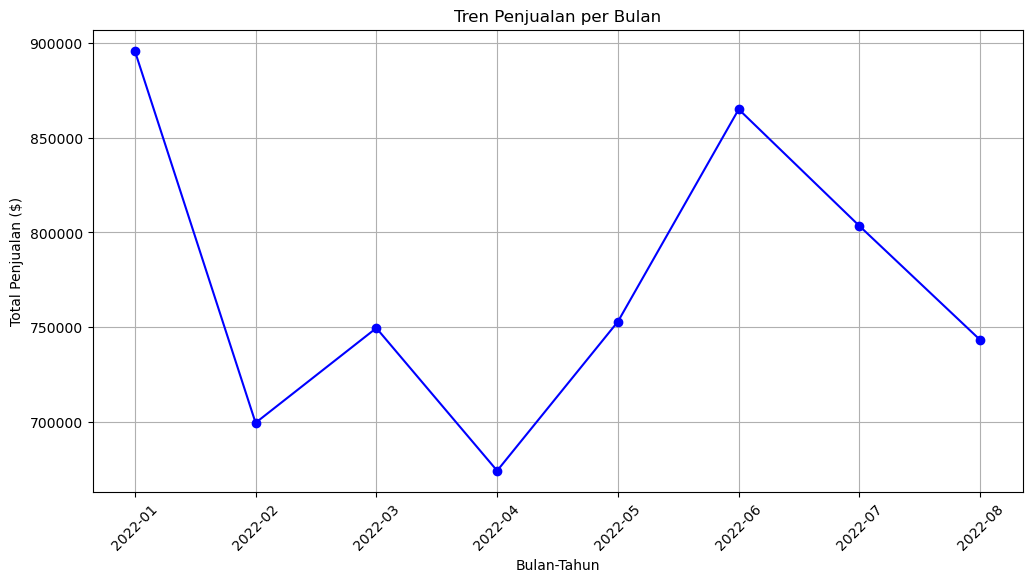

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tambahkan kolom bulan-tahun untuk agregasi
df["Month-Year"] = df["Date"].dt.to_period("M")

# Agregasi total penjualan per bulan
monthly_sales = df.groupby("Month-Year")["Amount"].sum().reset_index()

# Konversi Month-Year ke datetime untuk plotting
monthly_sales["Month-Year"] = monthly_sales["Month-Year"].astype(str)

# Plot grafik
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["Month-Year"], monthly_sales["Amount"], marker="o", linestyle="-", color="b")

# Format tampilan
plt.xticks(rotation=45)
plt.xlabel("Bulan-Tahun")
plt.ylabel("Total Penjualan ($)")
plt.title("Tren Penjualan per Bulan")
plt.grid(True)
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_15932\1896056.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Amount", y="Product", data=product_sales, palette="Blues_r")


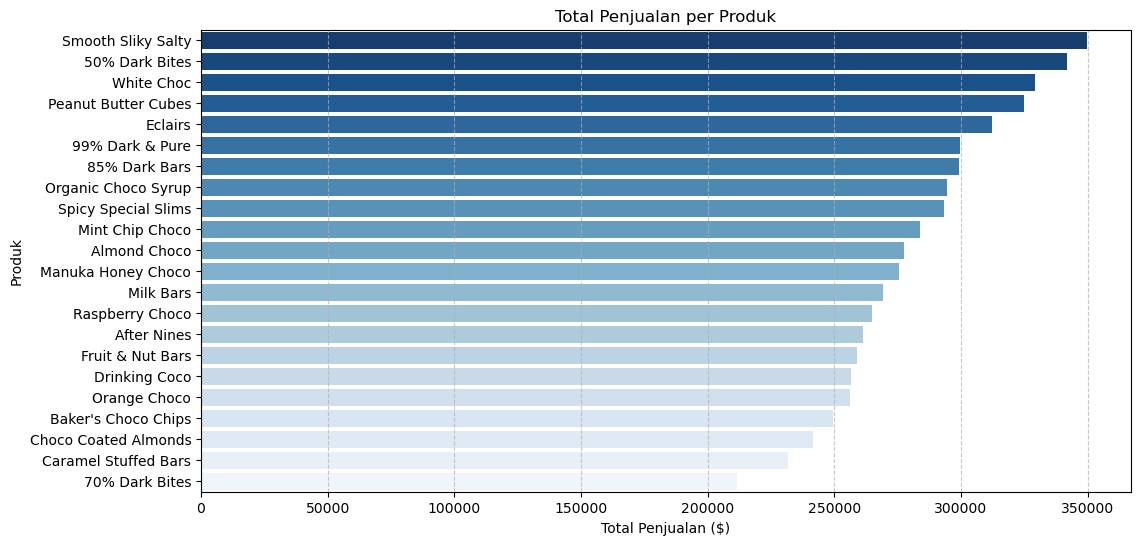

In [13]:
import seaborn as sns

# Agregasi total penjualan per produk
product_sales = df.groupby("Product")["Amount"].sum().reset_index()

# Urutkan berdasarkan total penjualan
product_sales = product_sales.sort_values(by="Amount", ascending=False)

# Plot grafik batang
plt.figure(figsize=(12, 6))
sns.barplot(x="Amount", y="Product", data=product_sales, palette="Blues_r")

# Format tampilan
plt.xlabel("Total Penjualan ($)")
plt.ylabel("Produk")
plt.title("Total Penjualan per Produk")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_15932\2658006821.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Amount", y="Sales Person", data=salesperson_sales, palette="Greens_r")


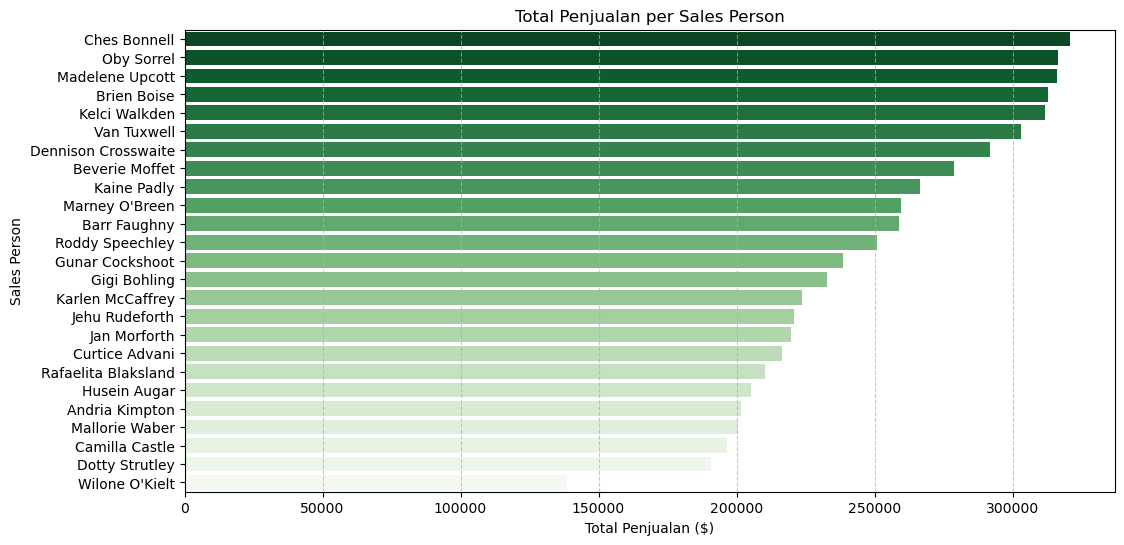

In [14]:
# Agregasi total penjualan per sales person
salesperson_sales = df.groupby("Sales Person")["Amount"].sum().reset_index()

# Urutkan berdasarkan total penjualan
salesperson_sales = salesperson_sales.sort_values(by="Amount", ascending=False)

# Plot grafik batang
plt.figure(figsize=(12, 6))
sns.barplot(x="Amount", y="Sales Person", data=salesperson_sales, palette="Greens_r")

# Format tampilan
plt.xlabel("Total Penjualan ($)")
plt.ylabel("Sales Person")
plt.title("Total Penjualan per Sales Person")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [15]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Month-Year
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022-01
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022-08
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022-07
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022-04
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022-02


C:\Users\USER\AppData\Local\Temp\ipykernel_15932\354900753.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Amount", y="Country", data=country_sales, palette="Oranges_r")


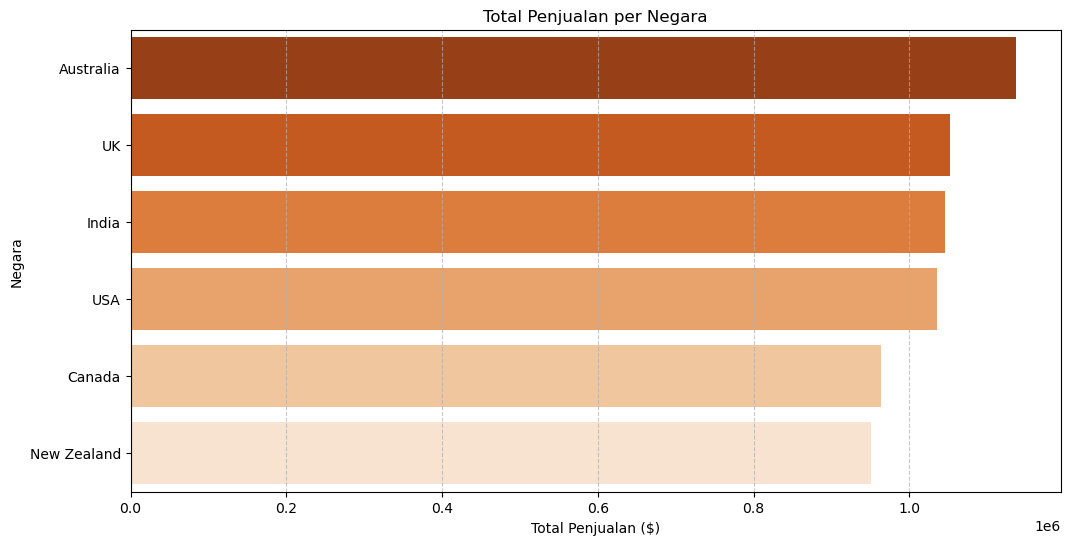

In [16]:
# Agregasi total penjualan per negara
country_sales = df.groupby("Country")["Amount"].sum().reset_index()

# Urutkan berdasarkan total penjualan
country_sales = country_sales.sort_values(by="Amount", ascending=False)

# Plot grafik batang
plt.figure(figsize=(12, 6))
sns.barplot(x="Amount", y="Country", data=country_sales, palette="Oranges_r")

# Format tampilan
plt.xlabel("Total Penjualan ($)")
plt.ylabel("Negara")
plt.title("Total Penjualan per Negara")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()